# 16. 이산배당 반영 MC — 배당 전후 비교 (200개 상품)

지금 MC 이론가는 배당을 넣지 않는다(`q = 0`). 기초자산 배당을 **이산배당**(배당락일에 주가가 배당만큼 하락)으로 넣어
다시 가격하고, 노트북 15 와 같은 형식으로 **배당 전후**를 비교한다.

| | 배당 전 (현행 방식) | 배당 후 |
|---|---|---|
| 배당 | **q = 0** (배당 없음) | 기초자산별 **이산배당**: 배당락일에 로그가격이 **log(1 − δ)** 만큼 하락, δ = 배당 ÷ 전일 종가 |
| 배당 스케줄 | – | 발행일 **이전** 최근 분배일 기준 1년 창의 배당락일·δ 를 **다음 기념일부터 만기까지 매년 반복** (미래 실제 배당 미사용) |
| 배당 출처 | – | 지수: 추종 ETF 분배금 (FEZ · SPY · FXI · 069500 · 1321.T · 2800.HK · QQQ), 회사: 종목 배당 (yfinance) |
| 나머지 | 일별 GBM · 촐레스키 · 180일 HV · 180일 상관 · NS 할인(콜 · 3개월 · 국고채 10년) · 40,000 경로 · seed=`mc_seed` | 동일 |

## 공통난수 — 배당만 다르게

세 가격 모두 노트북 5 의 인라인 엔진(커밋된 `mc` 재현 검증됨), **같은 경로·같은 시드**로 계산했다.
배당 수준과 시점을 나누려고 **연속 q** 변형도 가격했다. 연속 q 는 연간 총 로그하락을 이산배당과 똑같이 맞췄으므로
`연속 − 전` = **배당 수준 효과**, `이산 − 연속` = **배당 시점 효과**다.

표본은 기초자산 3개가 모두 배당 데이터가 있는 58,405개 중 발행일 전 구간에 고르게 뽑은 **200개**다.
무배당 2종(삼성바이오로직스 · LG에너지솔루션)과 DAX(총수익지수라 q≈0 이 맞음)가 들어간 상품은 뺐다.
결과는 `result/statistics/mc_discrete_div_200*.csv` (`scratch/mc_discrete_div.py`).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from util import file_manager as fm, plot as _plot     # import 만으로 dpi400·투명·PPT 밴드

FACE = 10000
BEF, AFT, MID = "#e07a5f", "#1f6f9c", "#2a9d8f"        # 노트북 15 와 같은 색
LB, LA = "before: q = 0 (current MC)", "after: discrete dividends"

d = pd.read_csv(fm.stat("mc_discrete_div_200"), encoding="utf-8-sig")
EV = pd.read_csv(fm.stat("mc_discrete_div_200_events"), encoding="utf-8-sig")
d["year"] = pd.to_datetime(d.isu_dt).dt.year
d["mc_bef"], d["mc_aft"] = d.mc_q0, d.mc_disc
d["err_bef"] = (d.fair - d.mc_bef) * FACE
d["err_aft"] = (d.fair - d.mc_aft) * FACE
d["err_cont"] = (d.fair - d.mc_cont) * FACE
Q = d[["q_1", "q_2", "q_3"]].values * 100

print(f"상품 {len(d)} | 발행 {d.isu_dt.min()} ~ {d.isu_dt.max()} | 상품당 배당락 {d.n_div_events.mean():.1f}회")
print(f"기초자산 연 배당수익률: 평균 {np.nanmean(Q):.2f}%, 중앙값 {np.nanmedian(Q):.2f}%  (바스켓 평균 {d.q_basket.mean()*100:.2f}%)")
print(f"재현 검증: |q=0 재현 − 커밋 mc| 평균 {(d.mc_q0 - d.mc_committed).abs().mean()*FACE:.1f}원, "
      f"최대 {(d.mc_q0 - d.mc_committed).abs().max()*FACE:.1f}원  → 비교 기준('전')은 같은 엔진의 q=0 재현값")

상품 200 | 발행 2015-01-05 ~ 2026-05-12 | 상품당 배당락 28.2회
기초자산 연 배당수익률: 평균 2.25%, 중앙값 2.12%  (바스켓 평균 2.25%)
재현 검증: |q=0 재현 − 커밋 mc| 평균 3.9원, 최대 25.4원  → 비교 기준('전')은 같은 엔진의 q=0 재현값


## 16-1. 전체 요약 — 오차가 줄었는가

`공정가 − MC` 가 0 에 가까울수록 MC 가 공정가를 잘 맞춘 것이다. 음수는 MC 과대평가.

In [2]:
def summ(e, mc):
    return {"mean_err_KRW": e.mean(), "median_err_KRW": e.median(), "MAE_KRW": e.abs().mean(),
            "RMSE_KRW": np.sqrt((e ** 2).mean()), "MAPE%": (e.abs() / (d.fair * FACE)).mean() * 100,
            "R2": r2_score(d.fair, mc)}


S = pd.DataFrame({"before (q=0)": summ(d.err_bef, d.mc_bef), "continuous q": summ(d.err_cont, d.mc_cont),
                  "after (discrete)": summ(d.err_aft, d.mc_aft)}).T
S.loc["after - before"] = S.loc["after (discrete)"] - S.loc["before (q=0)"]
S.to_csv(fm.stat("mc_div_summary"))
print(S.round(3).to_string())
better = (d.err_aft.abs() < d.err_bef.abs()).mean()
print(f"\n|오차| 가 줄어든 상품 {better*100:.1f}%  |  MC 가격 변화 (후 − 전) 평균 "
      f"{((d.mc_aft - d.mc_bef) * FACE).mean():+,.0f}원, 표준편차 {((d.mc_aft - d.mc_bef) * FACE).std():,.0f}원")

                  mean_err_KRW  median_err_KRW  MAE_KRW  RMSE_KRW  MAPE%     R2
before (q=0)          -514.225        -580.292  627.194   738.486  6.913 -1.494
continuous q          -370.372        -428.757  552.426   671.658  6.076 -1.063
after (discrete)      -369.979        -427.362  552.599   672.221  6.078 -1.066
after - before         144.246         152.930  -74.596   -66.265 -0.835  0.427

|오차| 가 줄어든 상품 82.0%  |  MC 가격 변화 (후 − 전) 평균 -144원, 표준편차 94원


## 16-2. `(공정가 − MC)` 히스토그램 — 배당 전후 겹침

노트북 15 와 같은 형식이다. 두 분포는 같은 구간(bin)을 쓴다.

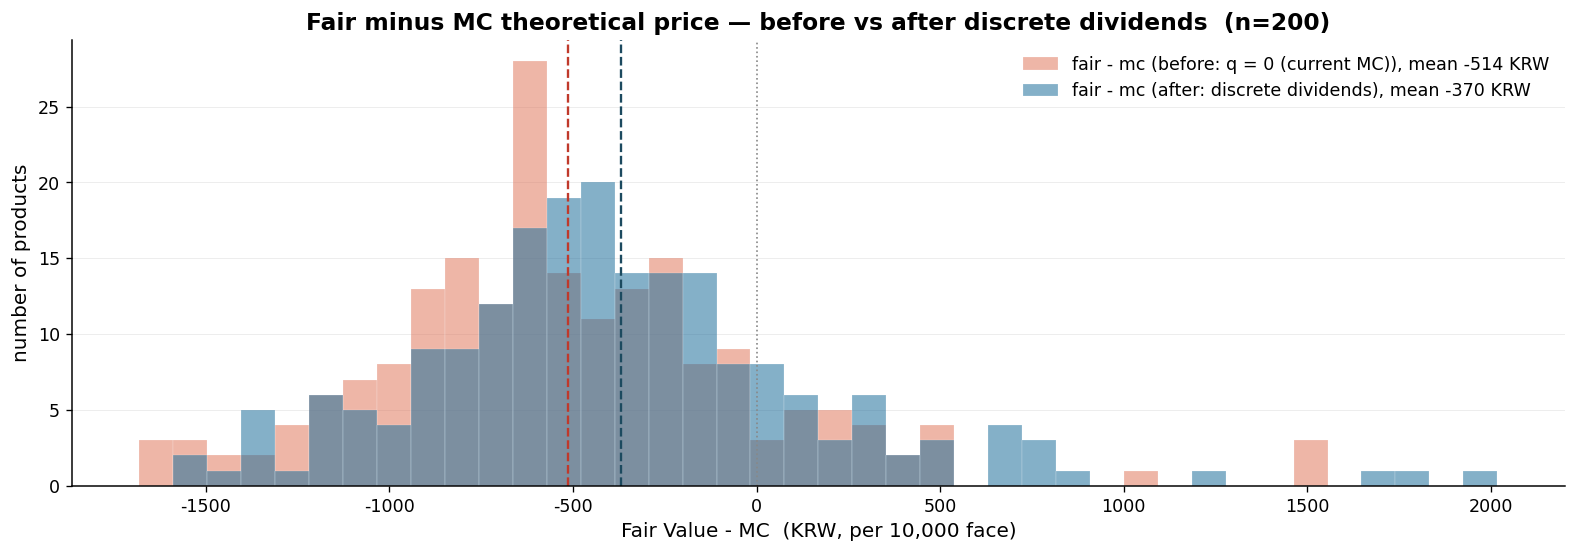

fair-mc 전 -514 | 후 -370 | 편향 변화 +144 KRW
saved -> mc_div_fair_minus_mc_hist.png


In [3]:
e_b, e_a = d.err_bef, d.err_aft
bins = np.linspace(min(e_b.min(), e_a.min()), max(e_b.max(), e_a.max()), 41)
fig, ax = plt.subplots(figsize=(13.333, 4.8))
ax.hist(e_b, bins=bins, color=BEF, alpha=.55, edgecolor="white", lw=.2,
        label=f"fair - mc ({LB}), mean {e_b.mean():,.0f} KRW")
ax.hist(e_a, bins=bins, color=AFT, alpha=.55, edgecolor="white", lw=.2,
        label=f"fair - mc ({LA}), mean {e_a.mean():,.0f} KRW")
ax.axvline(e_b.mean(), color="#c0392b", lw=1.4, ls="--"); ax.axvline(e_a.mean(), color="#1c4a5f", lw=1.4, ls="--")
ax.axvline(0, color="#888", lw=1, ls=":")
ax.set_xlabel("Fair Value - MC  (KRW, per 10,000 face)"); ax.set_ylabel("number of products")
ax.set_title(f"Fair minus MC theoretical price — before vs after discrete dividends  (n={len(d)})")
ax.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6); ax.legend()
fig.tight_layout(); fig.savefig(fm.image("mc_div_fair_minus_mc_hist")); plt.show()
print(f"fair-mc 전 {e_b.mean():,.0f} | 후 {e_a.mean():,.0f} | 편향 변화 {e_a.mean()-e_b.mean():+,.0f} KRW")
print("saved ->", fm.image("mc_div_fair_minus_mc_hist").name)

## 16-3. 가격구간별 오차 · MAPE — 배당 전후

노트북 1·15 는 **저가(위험) 구간에서 MC 가 크게 과대평가**하는 기울기를 역사변동성이 하방 스큐를 못 담는 흔적으로 봤다.
배당은 모든 상품의 선도가격을 비슷한 비율로 낮추므로, 편향 수준은 줄여도 기울기는 크게 바꾸지 못할 것으로 예상된다.
(200개라 구간당 약 33개 — 구간별 값은 노이즈가 있다.)

                 n  fair_mean  err_bef  err_aft  MAPE_bef  MAPE_aft
price_seg                                                          
(0.799, 0.885]  34       0.86  -993.04  -809.65     12.57     10.98
(0.885, 0.914]  33       0.90  -827.26  -681.76      9.60      8.29
(0.914, 0.934]  33       0.92  -587.16  -418.23      7.52      6.42
(0.934, 0.952]  33       0.94  -430.44  -292.25      5.63      4.60
(0.952, 0.98]   33       0.97  -239.91  -124.59      4.30      3.78
(0.98, 1.04]    34       1.00    -8.36   105.53      1.83      2.36


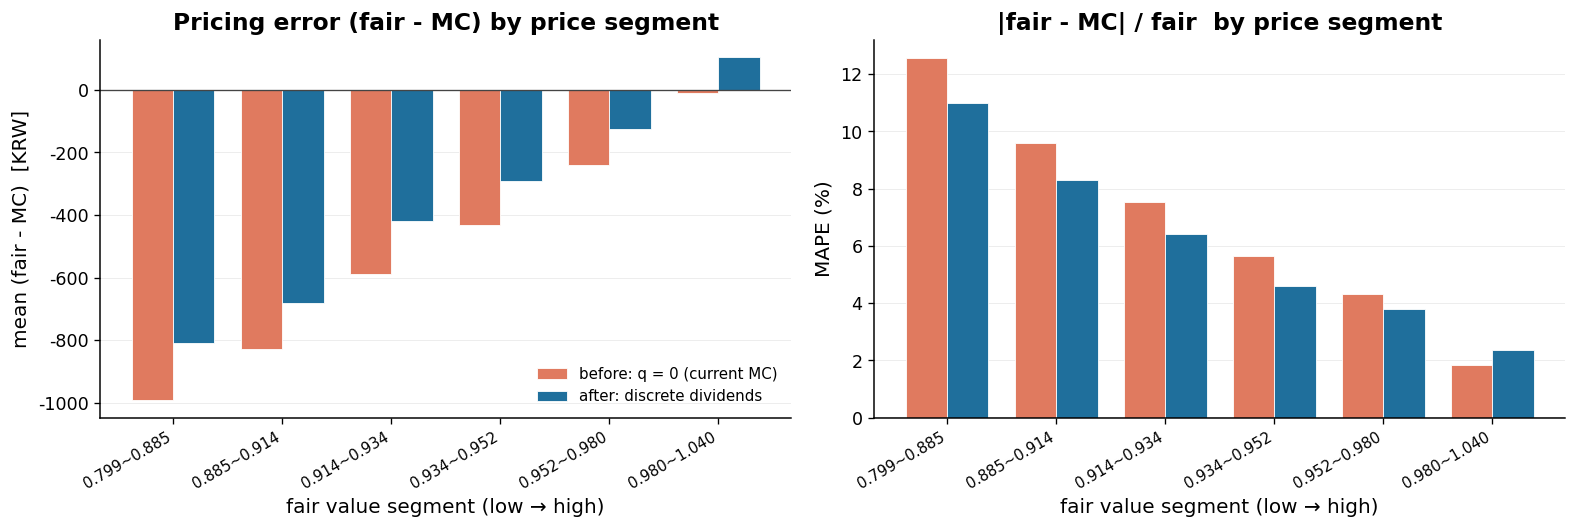

구간 기울기 (최안전 − 최위험 구간 평균오차): 전 985원 → 후 915원
saved -> mc_div_err_by_price_seg.png


In [4]:
d["price_seg"] = pd.qcut(d.fair, 6)
d["ape_bef"] = d.err_bef.abs() / (d.fair * FACE) * 100
d["ape_aft"] = d.err_aft.abs() / (d.fair * FACE) * 100
g = d.groupby("price_seg", observed=True).agg(
    n=("fair", "size"), fair_mean=("fair", "mean"),
    err_bef=("err_bef", "mean"), err_aft=("err_aft", "mean"),
    MAPE_bef=("ape_bef", "mean"), MAPE_aft=("ape_aft", "mean"))
g.to_csv(fm.stat("mc_div_by_price_seg"))
print(g.round(2).to_string())

xs = np.arange(len(g)); xl = [f"{iv.left:.3f}~{iv.right:.3f}" for iv in g.index]; w = .38
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))
for a, cb, ca, yl, tt in [(ax[0], "err_bef", "err_aft", "mean (fair - MC)  [KRW]", "Pricing error (fair - MC) by price segment"),
                          (ax[1], "MAPE_bef", "MAPE_aft", "MAPE (%)", "|fair - MC| / fair  by price segment")]:
    a.bar(xs - w/2, g[cb].values, w, color=BEF, edgecolor="white", linewidth=.5, label=LB)
    a.bar(xs + w/2, g[ca].values, w, color=AFT, edgecolor="white", linewidth=.5, label=LA)
    a.axhline(0, color="#444", lw=.8)
    a.set_xticks(xs); a.set_xticklabels(xl, rotation=30, fontsize=9, ha="right")
    a.set_ylabel(yl); a.set_xlabel("fair value segment (low → high)"); a.set_title(tt)
    a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)
ax[0].legend(fontsize=9, loc="lower right")
fig.tight_layout(); fig.savefig(fm.image("mc_div_err_by_price_seg")); plt.show()
print(f"구간 기울기 (최안전 − 최위험 구간 평균오차): 전 {g.err_bef.iloc[-1]-g.err_bef.iloc[0]:,.0f}원 → "
      f"후 {g.err_aft.iloc[-1]-g.err_aft.iloc[0]:,.0f}원")
print("saved ->", fm.image("mc_div_err_by_price_seg").name)

## 16-4. 배당이 어떻게 들어갔고, 무엇이 가격을 움직였나

왼쪽은 기초자산별 연 배당수익률(상품 × 3자산), 가운데는 투영된 이산배당이 **몇 월에 몰리는지**(로그하락 합의 월별 비중),
오른쪽은 MC 가격 변화의 분해다. 공통난수라 각 조각이 순수하게 그 요인의 몫이다.
막대는 상품별 변화의 **크기 |Δ| 평균**이고 괄호 안 숫자가 부호 있는 평균이다.

=== MC 가격 변화 분해 (원, 음수 = MC 가 싸짐) ===
                  mean  mean |Δ|   std
dividend level  -143.9     143.9  93.3
dividend timing   -0.4       7.5  10.5
total           -144.2     144.3  94.4


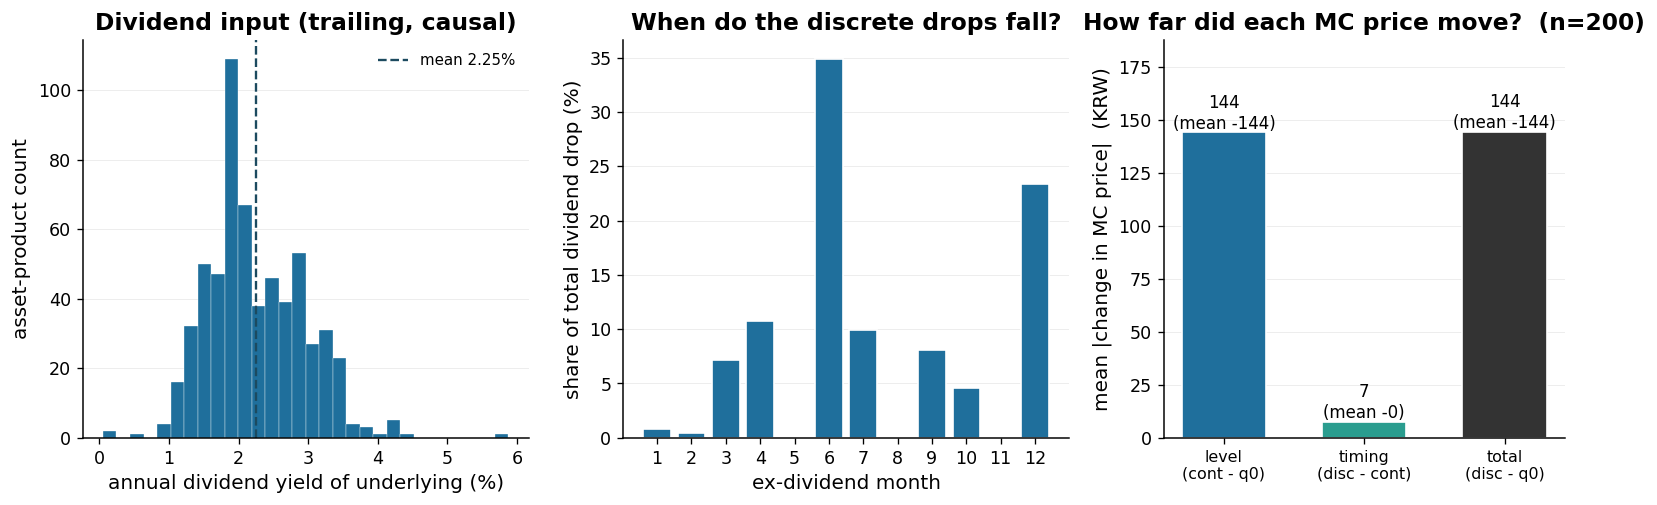

배당락 → 다음 조기상환 관찰일까지: 중앙값 88일, 사분위 44~135일 (배당락 5,647건)
saved -> mc_div_inputs_decomposition.png


In [5]:
DEC = pd.DataFrame({"dividend level": (d.mc_cont - d.mc_bef) * FACE,
                    "dividend timing": (d.mc_aft - d.mc_cont) * FACE,
                    "total": (d.mc_aft - d.mc_bef) * FACE})
DEC.describe().to_csv(fm.stat("mc_div_decomposition"))
print("=== MC 가격 변화 분해 (원, 음수 = MC 가 싸짐) ===")
print(pd.DataFrame({"mean": DEC.mean(), "mean |Δ|": DEC.abs().mean(), "std": DEC.std()}).round(1).to_string())

mon = EV.groupby("month").logdrop.sum().reindex(range(1, 13), fill_value=0); mon = mon / mon.sum() * 100
q = Q.ravel(); q = q[np.isfinite(q)]
fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.4), gridspec_kw={"width_ratios": [1, 1, .9]})
ax[0].hist(q, bins=30, color=AFT, edgecolor="white", lw=.2)
ax[0].axvline(q.mean(), color="#1c4a5f", lw=1.4, ls="--", label=f"mean {q.mean():.2f}%")
ax[0].set_xlabel("annual dividend yield of underlying (%)"); ax[0].set_ylabel("asset-product count")
ax[0].set_title("Dividend input (trailing, causal)"); ax[0].legend(fontsize=9)
ax[1].bar(range(1, 13), mon.values, color=AFT, edgecolor="white")
ax[1].set_xticks(range(1, 13)); ax[1].set_xlabel("ex-dividend month"); ax[1].set_ylabel("share of total dividend drop (%)")
ax[1].set_title("When do the discrete drops fall?")
absm, sgnm = DEC.abs().mean(), DEC.mean()
ax[2].bar(range(3), absm.values, color=[AFT, MID, "#333333"], edgecolor="white", width=.6)
for j, nm in enumerate(DEC.columns):
    ax[2].text(j, absm[nm], f"{absm[nm]:.0f}\n(mean {sgnm[nm]:+.0f})", ha="center", va="bottom", fontsize=10)
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(["level\n(cont - q0)", "timing\n(disc - cont)", "total\n(disc - q0)"], fontsize=9.5)
ax[2].set_ylim(0, absm.max() * 1.3); ax[2].set_ylabel("mean |change in MC price|  (KRW)")
ax[2].set_title(f"How far did each MC price move?  (n={len(d)})")
for a in ax:
    a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("mc_div_inputs_decomposition")); plt.show()
dn = EV.loc[EV.days_to_next_obs >= 0, "days_to_next_obs"]
print(f"배당락 → 다음 조기상환 관찰일까지: 중앙값 {dn.median():.0f}일, 사분위 {dn.quantile(.25):.0f}~{dn.quantile(.75):.0f}일 "
      f"(배당락 {len(dn):,}건)")
print("saved ->", fm.image("mc_div_inputs_decomposition").name)

## 16-5. 시기별 — 배당 효과는 매년 비슷한 평행이동인가

배당수익률은 해마다 2.0~2.5% 로 안정적이라, 배당 효과도 매년 비슷한 크기로 MC 를 낮출 것이다.
반면 공정가 − MC 편향은 해마다 크게 흔들린다(변동성 레짐). 배당이 그 흔들림까지 잡는지 본다.

       n  err_bef  err_aft  mae_bef  mae_aft  div_effect
year                                                    
2015  15   -282.0    -24.0    580.0    532.0      -258.0
2016  12   -372.0   -220.0    416.0    305.0      -153.0
2017  17   -716.0   -653.0    758.0    704.0       -63.0
2018  23   -527.0   -390.0    544.0    457.0      -136.0
2019  27   -533.0   -411.0    533.0    421.0      -122.0
2020  17    153.0    347.0    637.0    723.0      -194.0
2021  24   -930.0   -762.0    940.0    804.0      -168.0
2022  19   -838.0   -706.0    864.0    741.0      -132.0
2023  19   -703.0   -588.0    703.0    594.0      -116.0
2024  10   -372.0   -226.0    429.0    406.0      -145.0
2025  13   -139.0      5.0    261.0    246.0      -144.0
2026   4   -236.0   -160.0    279.0    214.0       -76.0


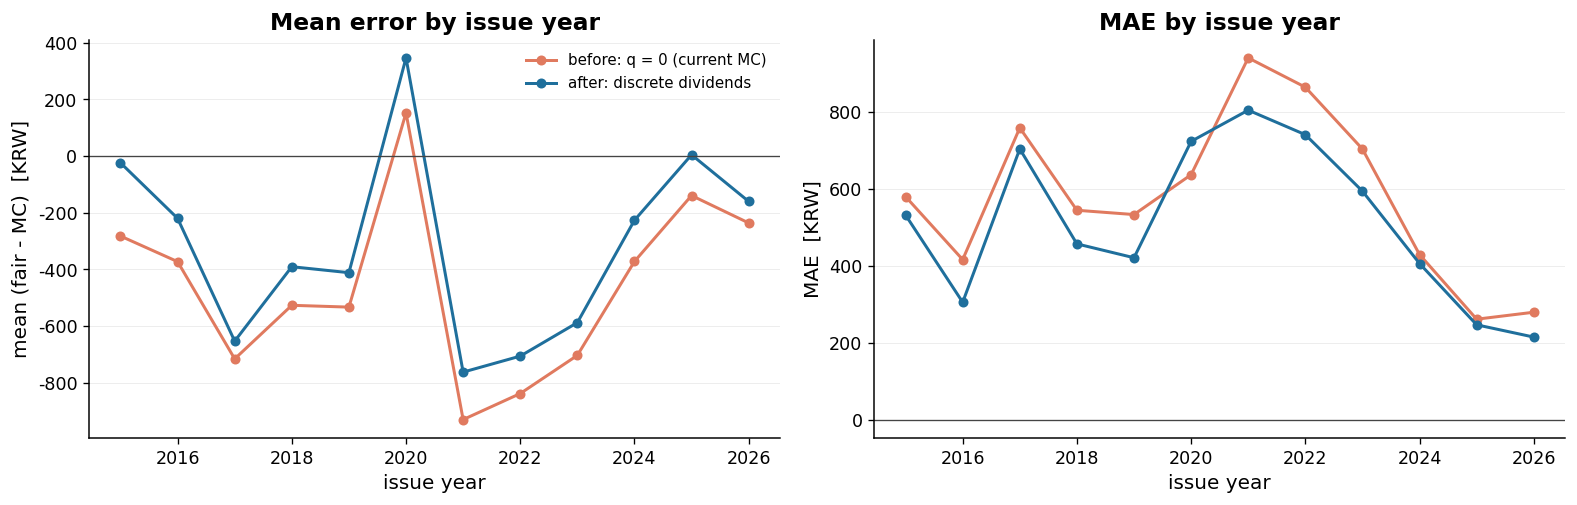

saved -> mc_div_by_year.png


In [6]:
t = d.groupby("year").agg(n=("fair", "size"), err_bef=("err_bef", "mean"), err_aft=("err_aft", "mean"),
                          mae_bef=("err_bef", lambda s: s.abs().mean()), mae_aft=("err_aft", lambda s: s.abs().mean()))
t["div_effect"] = (d.mc_aft - d.mc_bef).groupby(d.year).mean() * FACE
t.to_csv(fm.stat("mc_div_by_year"))
print(t.round(0).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.4))
for a, cb, ca, yl, tt in [(ax[0], "err_bef", "err_aft", "mean (fair - MC)  [KRW]", "Mean error by issue year"),
                          (ax[1], "mae_bef", "mae_aft", "MAE  [KRW]", "MAE by issue year")]:
    a.plot(t.index, t[cb], "o-", ms=5, lw=1.8, color=BEF, label=LB)
    a.plot(t.index, t[ca], "o-", ms=5, lw=1.8, color=AFT, label=LA)
    a.axhline(0, color="#444", lw=.8); a.set_xlabel("issue year"); a.set_ylabel(yl); a.set_title(tt)
    a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
ax[0].legend(fontsize=9)
fig.tight_layout(); fig.savefig(fm.image("mc_div_by_year")); plt.show()
print("saved ->", fm.image("mc_div_by_year").name)

## 16-6. 변동성 EWMA-120 · 상관 120일을 동시에 반영 — 2×2

노트북 15 의 자문안 정의(`module/features.py` 의 `vol_ewma` · `corr180(win=120)`)를 그대로 써서, 배당과 교차한 4가지를
같은 경로로 가격했다. 배당 효과 · 자문안 효과 · 동시 효과를 공통난수로 분리한다.

| | 현행 | 자문안 |
|---|---|---|
| 변동성 | 발행 전 **180 거래일** 단순 표준편차 × √252 | 발행 전 **120 거래일 EWMA** 표준편차 × √252 (span 120 → λ ≈ 0.9835, 반감기 ≈ 42 거래일) — 각 시장 자체 거래일 |
| 상관 | 3시장 **공통 거래일 180일** Pearson | 3시장 **공통 거래일 120일** Pearson (세 시장이 모두 열린 날 기준 약 6개월) |

입력 평균 — 변동성: HV180 18.57% → EWMA120 18.48%  |  상관: 180일 0.351 → 120일 0.346
                                      mean_err_KRW  median_err_KRW  MAE_KRW  RMSE_KRW  MAPE%     R2
HV180/corr180, q=0 (current)              -514.225        -580.292  627.194   738.486  6.913 -1.494
HV180/corr180, discrete div               -369.979        -427.362  552.599   672.221  6.078 -1.066
EWMA120/corr120, q=0 (advisory)           -502.552        -558.643  647.827   761.487  7.143 -1.652
EWMA120/corr120, discrete div (both)      -364.337        -435.478  587.835   706.978  6.462 -1.286

배당 효과 (이산 − q=0):   현행 변동성에서 -144원 | 자문안 변동성에서 -138원
자문안 효과 (EWMA − HV), q=0: 평균 -12원, 상품별 |Δ| 163원
자문안 효과 (EWMA − HV), 이산배당: 평균 -6원, 상품별 |Δ| 190원
|오차| 가 현행보다 줄어든 상품: 배당만 82.0% | 동시 64.5%


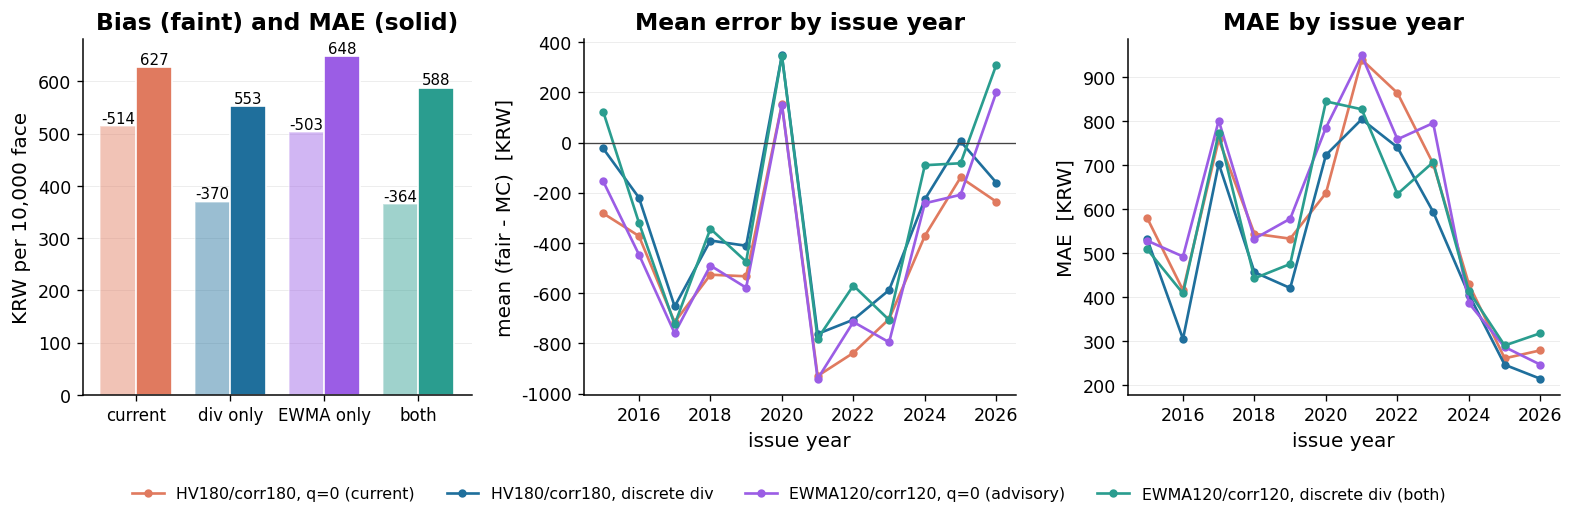

saved -> mc_div_2x2.png


In [7]:
VAR = {"HV180/corr180, q=0 (current)": "mc_q0", "HV180/corr180, discrete div": "mc_disc",
       "EWMA120/corr120, q=0 (advisory)": "mc_ew_q0", "EWMA120/corr120, discrete div (both)": "mc_ew_disc"}
COL = ["#e07a5f", "#1f6f9c", "#9b5de5", "#2a9d8f"]
print(f"입력 평균 — 변동성: HV180 {d.hv_mean.mean()*100:.2f}% → EWMA120 {d.ew_mean.mean()*100:.2f}%  |  "
      f"상관: 180일 {d.rho180.mean():.3f} → 120일 {d.rho120.mean():.3f}")
T2 = pd.DataFrame({lab: summ((d.fair - d[c]) * FACE, d[c]) for lab, c in VAR.items()}).T
T2.to_csv(fm.stat("mc_div_2x2"))
print(T2.round(3).to_string())
print(f"\n배당 효과 (이산 − q=0):   현행 변동성에서 {((d.mc_disc-d.mc_q0)*FACE).mean():+.0f}원 | 자문안 변동성에서 {((d.mc_ew_disc-d.mc_ew_q0)*FACE).mean():+.0f}원")
for lab, x in [("자문안 효과 (EWMA − HV), q=0", (d.mc_ew_q0 - d.mc_q0) * FACE), ("자문안 효과 (EWMA − HV), 이산배당", (d.mc_ew_disc - d.mc_disc) * FACE)]:
    print(f"{lab}: 평균 {x.mean():+.0f}원, 상품별 |Δ| {x.abs().mean():.0f}원")
print(f"|오차| 가 현행보다 줄어든 상품: 배당만 {((d.fair-d.mc_disc).abs() < (d.fair-d.mc_q0).abs()).mean()*100:.1f}% | "
      f"동시 {((d.fair-d.mc_ew_disc).abs() < (d.fair-d.mc_q0).abs()).mean()*100:.1f}%")

yr = {lab: ((d.fair - d[c]) * FACE).groupby(d.year) for lab, c in VAR.items()}
fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.4), gridspec_kw={"width_ratios": [.9, 1, 1]})
xs = np.arange(len(VAR)); w = .38
ax[0].bar(xs - w/2, T2.mean_err_KRW.abs().values, w, color=COL, alpha=.45, edgecolor="white", label="|mean error|")
ax[0].bar(xs + w/2, T2.MAE_KRW.values, w, color=COL, edgecolor="white", label="MAE")
for j, (b, m) in enumerate(zip(T2.mean_err_KRW.values, T2.MAE_KRW.values)):
    ax[0].text(j + w/2, m, f"{m:.0f}", ha="center", va="bottom", fontsize=9)
    ax[0].text(j - w/2, abs(b), f"{b:.0f}", ha="center", va="bottom", fontsize=9)
ax[0].set_xticks(xs); ax[0].set_xticklabels(["current", "div only", "EWMA only", "both"], fontsize=10)
ax[0].set_ylabel("KRW per 10,000 face"); ax[0].set_title("Bias (faint) and MAE (solid)")
for (lab, g), cc in zip(yr.items(), COL):
    ax[1].plot(g.mean().index, g.mean().values, "o-", ms=4, lw=1.6, color=cc, label=lab)
    ax[2].plot(g.apply(lambda s: s.abs().mean()).index, g.apply(lambda s: s.abs().mean()).values, "o-", ms=4, lw=1.6, color=cc, label=lab)
ax[1].axhline(0, color="#444", lw=.8); ax[1].set_xlabel("issue year"); ax[1].set_ylabel("mean (fair - MC)  [KRW]"); ax[1].set_title("Mean error by issue year")
ax[2].set_xlabel("issue year"); ax[2].set_ylabel("MAE  [KRW]"); ax[2].set_title("MAE by issue year")
for a in ax:
    a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
h, l = ax[1].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=4, fontsize=9.5, frameon=False, bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=(0, 0.08, 1, 1)); fig.savefig(fm.image("mc_div_2x2")); plt.show()
print("saved ->", fm.image("mc_div_2x2").name)

## 결론 — 배당은 편향을 줄이지만, 이산과 연속의 차이는 거의 없다

200개 상품, 공통난수(같은 경로) 기준.

| | 배당 전 (q = 0) | 연속 q | 배당 후 (이산) | 변화 (후 − 전) |
|---|---|---|---|---|
| 평균 오차 (공정가 − MC) | -514원 | -370원 | -370원 | **+144원** |
| MAE | 627원 | 552원 | 553원 | **-75원** |
| MAPE | 6.91% | 6.08% | 6.08% | -0.84%p |
| R² (공정가 vs MC) | -1.494 | -1.063 | -1.066 | +0.427 |
| \|오차\| 가 줄어든 상품 | | | 82.0% | |
| 가격구간 기울기 (최안전 − 최위험) | 985원 | | 915원 | -70원 |

1. **배당을 넣으면 MC 가 평균 144원 싸진다.** 기초자산 연 배당수익률 평균 2.25% 가 선도가격을 낮춰
   조기상환 확률을 줄이기 때문이다. 과대평가 편향이 -514 → -370원으로
   28% 줄고 MAE 도 627 → 553원으로 준다.
   배당은 시장 표준 입력이라, 앞서 비방어적이라 되돌린 변동성 프리미엄 보정과 달리 학술적으로 방어할 수 있는 교정이다.
2. **이산과 연속의 차이는 거의 없다.** 연간 총 배당을 같게 맞추면 시점 효과는 평균 -0.4원, 상품별 |Δ| 7.5원으로
   수준 효과(|Δ| 144원)의 1/19 이다. 배당락은 특정 달에 몰리지만(6월 35%, 12월 23%, 4월 11%),
   조기상환 관찰이 6개월 간격이라 관찰 시점까지 누적된 배당은 연속 q 와 거의 같다
   (배당락에서 다음 관찰일까지 중앙값 88일). **이 프레임워크에서는 연속 q 로 충분하다.**
3. **편향의 시기 변동은 그대로다.** 배당 효과는 연도별 -63 ~ -258원의 평행이동이라,
   해마다 크게 흔들리는 편향 자체는 못 잡는다. 이미 MC 가 공정가보다 낮았던 해에는 오히려 나빠진다
   (|평균 오차| 가 커진 해: 2020). 남은 편향은 변동성 레짐·스큐 쪽이며,
   같은 편향을 기간구조 IV(노트북 14)는 −556 → −190원까지 줄였다.
4. **가격구간 기울기도 거의 그대로다** (985 → 915원). 배당은 모든 구간의 선도가격을 비슷하게 낮춰
   수준만 옮기고, 저가(위험) 구간 과대평가라는 스큐 흔적은 남는다.
5. **EWMA-120 · 상관 120일을 함께 넣으면 오히려 나빠진다 (16-6).**

   | | q = 0 | 이산배당 |
   |---|---|---|
   | HV180 · 상관180 (현행) | -514원 / MAE 627원 | **-370원 / MAE 553원** |
   | EWMA120 · 상관120 (자문안) | -503원 / MAE 648원 | -364원 / MAE 588원 |

   배당 효과는 변동성 정의와 무관하게 거의 같다(현행 -144원, 자문안 -138원) — 두 요인은 서로 독립적으로 더해진다.
   자문안은 평균 수준은 180일 HV 와 같아(변동성 평균 18.57% → 18.48%) 편향을 -6원만 옮기면서
   상품별로 190원씩 흔들어 MAE 를 +35원 늘린다(노트북 15 전 상품 결과와 같은 결론).
   **최선 조합은 현행 변동성·상관 + 이산배당(또는 연속 q)** 이다.

**한계**: 200개 표본(구간·연도별 값은 노이즈가 있음). 지수 배당 시점은 추종 ETF 분배일 기준이라 실제 구성종목 배당락일과
1~3개월 차이가 날 수 있다 — 다만 시점 효과 자체가 수 원 수준이라 결론을 바꾸기는 어렵다. 할인은 현행 NS 커브(콜 · 3개월 · 국고채 10년)이며,
순수 국고채 1·3·5·10년 NS 커브는 ECOS 인증키가 있어야 만들 수 있다.